In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
# --- Allen's data in solar units ---
M_tab = np.array([10**(-1.), 10**(-0.67), 10**(-0.41), 10**(-0.33), 10**(-0.16), 10**(-0.11), 10**(-0.03), 1., 10**0.04, 10**0.11, 10**0.23, 10**0.32, 10**0.51])
R_tab = np.array([10**(-0.9), 10**(-0.5), 10**(-0.3), 10**(-0.2), 10**(-0.13), 10**(-0.07), 10**(-0.03), 1., 10**0.02, 10**0.08, 10**0.13, 10**0.24, 10**0.4])
L_tab = np.array([10**(-3.1), 10**(-2.1), 10**(-1.5), 10**(-1.2), 10**(-0.8), 10**(-0.4), 10**(-0.1), 1., 10**0.1, 10**0.4, 10**0.8, 10**1.3, 10**1.9])

logM_tab, logR_tab, logL_tab = np.log10(M_tab), np.log10(R_tab), np.log10(L_tab)
R_Sun = 1.0  # [R_sun]
L_Sun = 1.0  # [L_sun]

def stellar_props(k1):
    logk1 = np.log10(k1)
    logR  = np.interp(logk1, logM_tab, logR_tab)
    logL  = np.interp(logk1, logM_tab, logL_tab)
    R_star_solar = 10**logR
    L_star_solar = 10**logL
    return R_star_solar, L_star_solar

# selected masses
k1 = np.array([0.25, 0.5, 1.0, 2.0])
R_allen, L_allen = stellar_props(k1)


In [12]:
# --- Girardi et al. (2000) ZAMS data ---
# download 'mstracks.dat.gz' from VizieR (J/A+AS/141/371)
# https://cdsarc.cds.unistra.fr/ftp/J/A+AS/141/371/mstracks.dat.gz
cols = ["Overshoot","Mass","Z","Y","Age","logL","logTeff","logg","logTc","logrho","XcYc",
        "XcC","XcO","Qconv","Qdisc","logLH","Q1H","Q2H","logLHe","Q1He","Q2He","logLC","logLnu",
        "QTmax","Stage"]
df = pd.read_csv('mstracks.dat', 
                 delim_whitespace=True, 
                 comment='#', 
                 names=cols, 
                 na_values='null')

# Extract ZAMS for solar metallicity
df_zams = df[(df["Stage"]=="ZAMS") & (np.isclose(df["Z"], 0.019))]
M_gir = df_zams["Mass"].values
logL_gir = df_zams["logL"].values
logT_gir = df_zams["logTeff"].values

# Compute R/R_sun from L and Teff
#   L ∝ R^2 T^4  ⇒  R = sqrt(L) * (T_sun / T)^2
T_sun = 5772  # K
L_gir_solar = 10**logL_gir
T_gir = 10**logT_gir
R_gir_solar = np.sqrt(L_gir_solar) * (T_sun / T_gir)**2

# Sort Girardi data by mass for interpolation
sort_idx = np.argsort(M_gir)
M_gir_sorted = M_gir[sort_idx]
R_gir_sorted = R_gir_solar[sort_idx]
L_gir_sorted = L_gir_solar[sort_idx]

# Interpolate Girardi ZAMS at the same k1 masses
R_girardi, L_girardi = (
    np.interp(k1, M_gir_sorted, R_gir_sorted),
    np.interp(k1, M_gir_sorted, L_gir_sorted),
)

# --- Print interpolated values ---
print(" M/M_sun |   R_allen   L_allen   R_girardi   L_girardi")
for m, Ra, La, Rg, Lg in zip(k1, R_allen, L_allen, R_girardi, L_girardi):
    print(f"{m:7.2f} | {Ra:8.3f} {La:8.3f} {Rg:10.3f} {Lg:12.3f}")

 M/M_sun |   R_allen   L_allen   R_girardi   L_girardi
   0.25 |    0.357    0.011      0.249        0.009
   0.50 |    0.649    0.074      0.432        0.041
   1.00 |    1.000    1.000      0.879        0.684
   2.00 |    1.647   15.653      1.679       18.239


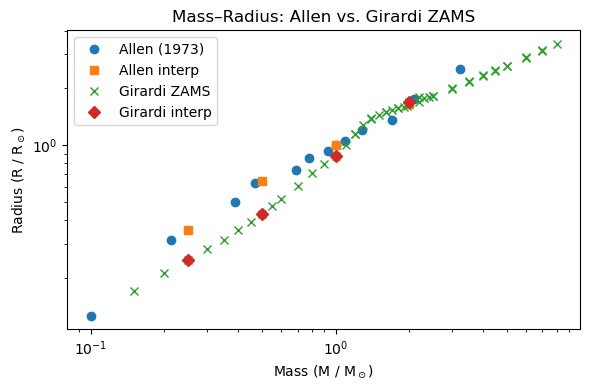

In [13]:
# --- Plot Mass–Radius comparison ---
plt.figure(figsize=(6,4))
plt.loglog(M_tab, R_tab,  'o', label="Allen (1973)")
plt.loglog(k1,    R_allen,'s', label="Allen interp")
plt.loglog(M_gir_sorted, R_gir_sorted, 'x', label="Girardi ZAMS")
plt.loglog(k1,    R_girardi, 'D', label="Girardi interp")
plt.xlabel("Mass (M / M$_\odot$)")
plt.ylabel("Radius (R / R$_\odot$)")
plt.title("Mass–Radius: Allen vs. Girardi ZAMS")
plt.legend()
plt.tight_layout()

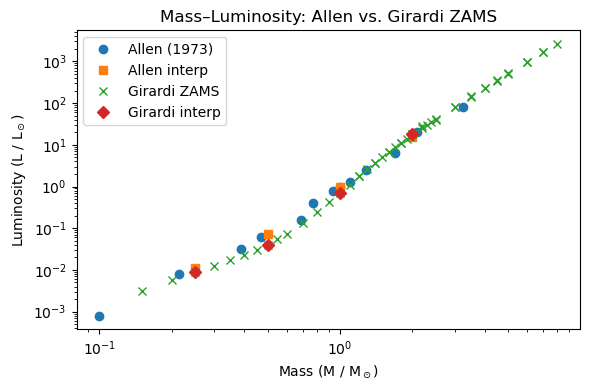

In [14]:
# --- Plot Mass–Luminosity comparison ---
plt.figure(figsize=(6,4))
plt.loglog(M_tab, L_tab,  'o', label="Allen (1973)")
plt.loglog(k1,    L_allen,'s', label="Allen interp")
plt.loglog(M_gir_sorted, L_gir_solar[sort_idx], 'x', label="Girardi ZAMS")
plt.loglog(k1,    L_girardi, 'D', label="Girardi interp")
plt.xlabel("Mass (M / M$_\odot$)")
plt.ylabel("Luminosity (L / L$_\odot$)")
plt.title("Mass–Luminosity: Allen vs. Girardi ZAMS")
plt.legend()
plt.tight_layout()

plt.show()
